Імпорти

In [24]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import MODEL_RESULTS_PATH

1. Завантажуємо загальну таблицю

In [25]:
results_df = pd.read_csv(MODEL_RESULTS_PATH)

results_df

,model,parameters,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,train_time_sec,variant,split,n_features,inference_time_sec
0,DistilBERT,"{""checkpoint"": ""distilbert-base-uncased"", ""epo...",0.909416,0.909147,0.909147,0.914840,0.909416,NaN,fine-tuned,test,NaN,5.714908
1,DistilBERT,"{""checkpoint"": ""distilbert-base-uncased"", ""epo...",0.906500,0.900707,0.905698,0.913445,0.898439,420.774839,fine-tuned,validation,NaN,NaN
2,TF-IDF + Linear SVM,"{""C"": 1.0, ""min_df"": 1, ""ngram_range"": [1, 1]}",0.887987,0.887864,0.887864,0.892381,0.887987,NaN,tuned,test,2158.0,0.021133
3,TF-IDF + Logistic Regression,"{""C"": 2.0, ""min_df"": 2, ""ngram_range"": [1, 1],...",0.881818,0.881908,0.881908,0.887893,0.881818,NaN,tuned,test,1331.0,0.016299
4,TF-IDF + Linear SVM,"{""classifier__C"": 1.0, ""tfidf__min_df"": 1, ""tf...",0.879000,0.873237,0.878779,0.881031,0.871352,3.870460,tuned,validation,2158.0,NaN
5,TF-IDF + Linear SVM,"{""C"": 1.0, ""min_df"": 2, ""ngram_range"": [1, 2],...",0.875500,0.870909,0.875092,0.879338,0.868093,0.367386,baseline,validation,8913.0,NaN
6,TF-IDF + Logistic Regression,"{""classifier__C"": 2.0, ""tfidf__min_df"": 2, ""tf...",0.867500,0.862007,0.867527,0.874387,0.858843,15.551374,tuned,validation,1331.0,NaN
7,TF-IDF + Logistic Regression,"{""C"": 1.0, ""min_df"": 2, ""ngram_range"": [1, 2],...",0.841000,0.829135,0.839451,0.854706,0.824639,2.555273,baseline,validation,8913.0,NaN
8,DummyClassifier,"{""strategy"": ""most_frequent""}",0.019000,0.000484,0.000709,0.000247,0.012987,0.001041,baseline,validation,NaN,NaN
9,DummyClassifier,"{""strategy"": ""most_frequent""}",0.012987,0.000333,0.000333,0.000169,0.012987,0.001041,baseline,test,NaN,NaN


In [26]:
results_df[
    [
        "model",
        "variant",
        "split",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "train_time_sec",
    ]
].sort_values(
    ["split", "macro_f1"],
    ascending=[True, False],
)

,model,variant,split,accuracy,macro_f1,weighted_f1,train_time_sec
0,DistilBERT,fine-tuned,test,0.909416,0.909147,0.909147,NaN
2,TF-IDF + Linear SVM,tuned,test,0.887987,0.887864,0.887864,NaN
3,TF-IDF + Logistic Regression,tuned,test,0.881818,0.881908,0.881908,NaN
9,DummyClassifier,baseline,test,0.012987,0.000333,0.000333,0.001041
1,DistilBERT,fine-tuned,validation,0.906500,0.900707,0.905698,420.774839
4,TF-IDF + Linear SVM,tuned,validation,0.879000,0.873237,0.878779,3.870460
5,TF-IDF + Linear SVM,baseline,validation,0.875500,0.870909,0.875092,0.367386
6,TF-IDF + Logistic Regression,tuned,validation,0.867500,0.862007,0.867527,15.551374
7,TF-IDF + Logistic Regression,baseline,validation,0.841000,0.829135,0.839451,2.555273
8,DummyClassifier,baseline,validation,0.019000,0.000484,0.000709,0.001041


In [27]:
results_df.groupby(
    ["model", "variant"]
)["split"].unique()

model                         variant   
DistilBERT                    fine-tuned    [test, validation]
DummyClassifier               baseline      [validation, test]
TF-IDF + Linear SVM           baseline            [validation]
                              tuned         [test, validation]
TF-IDF + Logistic Regression  baseline            [validation]
                              tuned         [test, validation]
Name: split, dtype: object

Якщо є дублікати

In [ ]:
results_df = results_df.drop_duplicates(
    subset=["model", "variant", "split"],
    keep="last",
)

2. Вибираємо лише фінальні версії моделей

In [28]:
final_experiments = [
    ("DummyClassifier", "baseline"),
    ("TF-IDF + Logistic Regression", "tuned"),
    ("TF-IDF + Linear SVM", "tuned"),
    ("DistilBERT", "fine-tuned"),
]

final_results = pd.concat(
    [
        results_df[
            (results_df["model"] == model)
            & (results_df["variant"] == variant)
        ]
        for model, variant in final_experiments
    ],
    ignore_index=True,
)

final_results[
    [
        "model",
        "variant",
        "split",
        "accuracy",
        "macro_f1",
        "weighted_f1",
    ]
].sort_values(
    ["split", "macro_f1"],
    ascending=[True, False],
)

,model,variant,split,accuracy,macro_f1,weighted_f1
6,DistilBERT,fine-tuned,test,0.909416,0.909147,0.909147
4,TF-IDF + Linear SVM,tuned,test,0.887987,0.887864,0.887864
2,TF-IDF + Logistic Regression,tuned,test,0.881818,0.881908,0.881908
1,DummyClassifier,baseline,test,0.012987,0.000333,0.000333
7,DistilBERT,fine-tuned,validation,0.906500,0.900707,0.905698
5,TF-IDF + Linear SVM,tuned,validation,0.879000,0.873237,0.878779
3,TF-IDF + Logistic Regression,tuned,validation,0.867500,0.862007,0.867527
0,DummyClassifier,baseline,validation,0.019000,0.000484,0.000709


3. Формуємо таблицю validation/test

In [29]:
comparison_df = final_results.pivot_table(
    index=["model", "variant"],
    columns="split",
    values=[
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "macro_precision",
        "macro_recall",
    ],
    aggfunc="last",
)

comparison_df.columns = [
    f"{metric}_{split}"
    for metric, split in comparison_df.columns
]

comparison_df = (
    comparison_df
    .reset_index()
    .sort_values(
        "macro_f1_test",
        ascending=False,
    )
)

comparison_df

,model,variant,accuracy_test,accuracy_validation,macro_f1_test,macro_f1_validation,macro_precision_test,macro_precision_validation,macro_recall_test,macro_recall_validation,weighted_f1_test,weighted_f1_validation
0,DistilBERT,fine-tuned,0.909416,0.9065,0.909147,0.900707,0.914840,0.913445,0.909416,0.898439,0.909147,0.905698
2,TF-IDF + Linear SVM,tuned,0.887987,0.8790,0.887864,0.873237,0.892381,0.881031,0.887987,0.871352,0.887864,0.878779
3,TF-IDF + Logistic Regression,tuned,0.881818,0.8675,0.881908,0.862007,0.887893,0.874387,0.881818,0.858843,0.881908,0.867527
1,DummyClassifier,baseline,0.012987,0.0190,0.000333,0.000484,0.000169,0.000247,0.012987,0.012987,0.000333,0.000709


4. Залишаємо основні колонки

In [30]:
main_comparison = comparison_df[
    [
        "model",
        "variant",
        "accuracy_validation",
        "accuracy_test",
        "macro_f1_validation",
        "macro_f1_test",
        "weighted_f1_validation",
        "weighted_f1_test",
    ]
].copy()

main_comparison

,model,variant,accuracy_validation,accuracy_test,macro_f1_validation,macro_f1_test,weighted_f1_validation,weighted_f1_test
0,DistilBERT,fine-tuned,0.9065,0.909416,0.900707,0.909147,0.905698,0.909147
2,TF-IDF + Linear SVM,tuned,0.8790,0.887987,0.873237,0.887864,0.878779,0.887864
3,TF-IDF + Logistic Regression,tuned,0.8675,0.881818,0.862007,0.881908,0.867527,0.881908
1,DummyClassifier,baseline,0.0190,0.012987,0.000484,0.000333,0.000709,0.000333


5. Різниця між validation і test

In [31]:
main_comparison["macro_f1_gap"] = (
    main_comparison["macro_f1_test"]
    - main_comparison["macro_f1_validation"]
)

main_comparison["accuracy_gap"] = (
    main_comparison["accuracy_test"]
    - main_comparison["accuracy_validation"]
)

main_comparison[
    [
        "model",
        "variant",
        "macro_f1_validation",
        "macro_f1_test",
        "macro_f1_gap",
        "accuracy_validation",
        "accuracy_test",
        "accuracy_gap",
    ]
]

,model,variant,macro_f1_validation,macro_f1_test,macro_f1_gap,accuracy_validation,accuracy_test,accuracy_gap
0,DistilBERT,fine-tuned,0.900707,0.909147,0.008439,0.9065,0.909416,0.002916
2,TF-IDF + Linear SVM,tuned,0.873237,0.887864,0.014627,0.8790,0.887987,0.008987
3,TF-IDF + Logistic Regression,tuned,0.862007,0.881908,0.019902,0.8675,0.881818,0.014318
1,DummyClassifier,baseline,0.000484,0.000333,-0.000151,0.0190,0.012987,-0.006013


6. Графік Macro F1: validation проти test

In [32]:
macro_f1_plot_df = main_comparison.melt(
    id_vars=["model", "variant"],
    value_vars=[
        "macro_f1_validation",
        "macro_f1_test",
    ],
    var_name="split",
    value_name="macro_f1",
)

macro_f1_plot_df["split"] = (
    macro_f1_plot_df["split"]
    .str.replace("macro_f1_", "", regex=False)
    .str.title()
)

macro_f1_plot_df["experiment"] = (
    macro_f1_plot_df["model"]
    + " — "
    + macro_f1_plot_df["variant"]
)

Для кращої видимості Dummy не показуємо на графіку

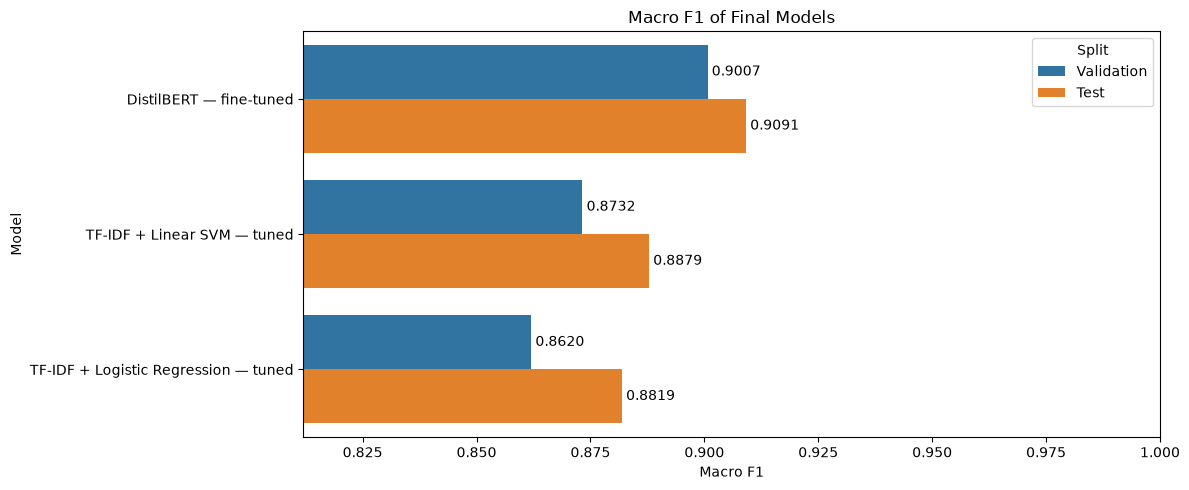

In [33]:
trained_models_plot_df = macro_f1_plot_df[
    macro_f1_plot_df["model"] != "DummyClassifier"
]

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=trained_models_plot_df,
    x="macro_f1",
    y="experiment",
    hue="split",
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3,
    )

minimum_score = trained_models_plot_df["macro_f1"].min()

plt.xlim(max(0, minimum_score - 0.05), 1)
plt.title("Macro F1 of Final Models")
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.legend(title="Split")

plt.tight_layout()
plt.show()

7. Фінальний рейтинг за test Macro F1

In [34]:
test_ranking = (
    final_results[
        final_results["split"] == "test"
    ]
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

test_ranking[
    [
        "model",
        "variant",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "macro_precision",
        "macro_recall",
        "inference_time_sec",
    ]
]

,model,variant,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,inference_time_sec
0,DistilBERT,fine-tuned,0.909416,0.909147,0.909147,0.914840,0.909416,5.714908
1,TF-IDF + Linear SVM,tuned,0.887987,0.887864,0.887864,0.892381,0.887987,0.021133
2,TF-IDF + Logistic Regression,tuned,0.881818,0.881908,0.881908,0.887893,0.881818,0.016299
3,DummyClassifier,baseline,0.012987,0.000333,0.000333,0.000169,0.012987,NaN


In [35]:
test_ranking.insert(
    0,
    "rank",
    range(1, len(test_ranking) + 1),
)

test_ranking

,rank,model,parameters,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,train_time_sec,variant,split,n_features,inference_time_sec
0,1,DistilBERT,"{""checkpoint"": ""distilbert-base-uncased"", ""epo...",0.909416,0.909147,0.909147,0.914840,0.909416,NaN,fine-tuned,test,NaN,5.714908
1,2,TF-IDF + Linear SVM,"{""C"": 1.0, ""min_df"": 1, ""ngram_range"": [1, 1]}",0.887987,0.887864,0.887864,0.892381,0.887987,NaN,tuned,test,2158.0,0.021133
2,3,TF-IDF + Logistic Regression,"{""C"": 2.0, ""min_df"": 2, ""ngram_range"": [1, 1],...",0.881818,0.881908,0.881908,0.887893,0.881818,NaN,tuned,test,1331.0,0.016299
3,4,DummyClassifier,"{""strategy"": ""most_frequent""}",0.012987,0.000333,0.000333,0.000169,0.012987,0.001041,baseline,test,NaN,NaN


8. Перевірка узгодженості Accuracy та Macro F1

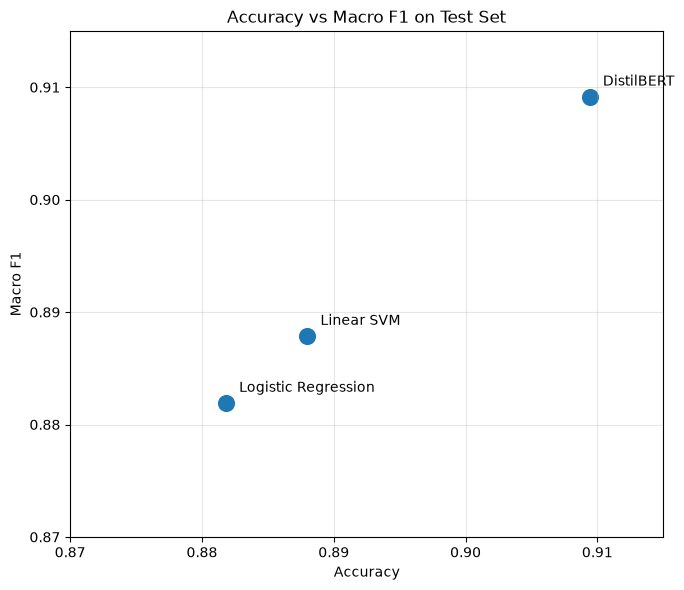

In [44]:
plt.figure(figsize=(7, 6))

plot_df = test_ranking[
    test_ranking["model"] != "DummyClassifier"
].copy()

sns.scatterplot(
    data=plot_df,
    x="accuracy",
    y="macro_f1",
    s=180,
)

for _, row in plot_df.iterrows():
    plt.text(
        row["accuracy"] + 0.001,
        row["macro_f1"] + 0.001,
        row["model"].replace("TF-IDF + ", ""),
        fontsize=10,
    )

plt.title("Accuracy vs Macro F1 on Test Set")

plt.xlabel("Accuracy")
plt.ylabel("Macro F1")

plt.xlim(0.87, 0.915)
plt.ylim(0.87, 0.915)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

9. Збереження фінальної таблиці

In [37]:
final_metrics_path = (
    PROJECT_ROOT
    / "reports"
    / "metrics"
    / "final_model_comparison.csv"
)

main_comparison.to_csv(
    final_metrics_path,
    index=False,
)

print(final_metrics_path)

/Users/oleh/PycharmProjects/banking-intent-classification/reports/metrics/final_model_comparison.csv


In [38]:
test_ranking.to_csv(
    PROJECT_ROOT
    / "reports"
    / "metrics"
    / "test_model_ranking.csv",
    index=False,
)

10. Графік Macro F1

In [45]:
name_mapping = {
    "TF-IDF + Logistic Regression": "Logistic\nRegression",
    "TF-IDF + Linear SVM": "Linear\nSVM",
    "DistilBERT": "DistilBERT",
}

plot_df = main_comparison.copy()

plot_df["Model"] = plot_df["model"].map(name_mapping)

plot_df = plot_df.sort_values(
    "macro_f1_test",
    ascending=True,
)

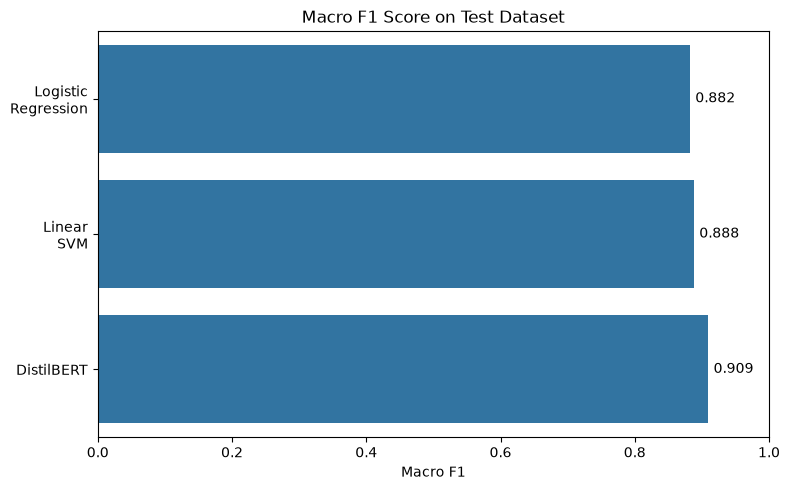

In [46]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_df,
    x="macro_f1_test",
    y="Model",
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=4,
    )

plt.title("Macro F1 Score on Test Dataset")
plt.xlabel("Macro F1")
plt.ylabel("")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

10. Приріст відносно Logistic Regression

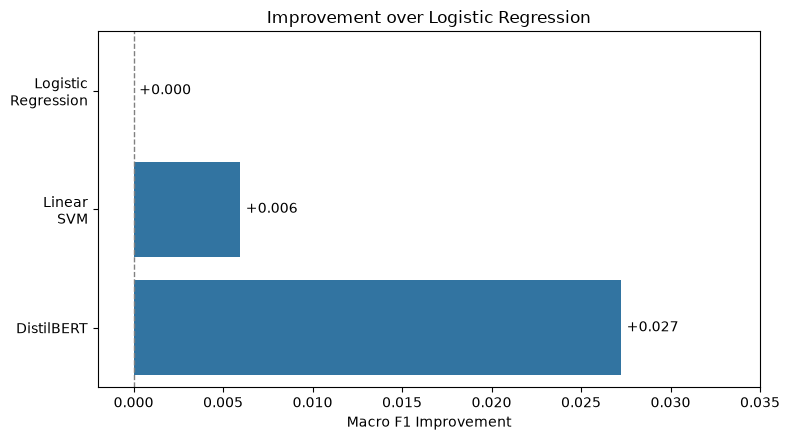

In [41]:
baseline_score = (
    main_comparison.loc[
        main_comparison["model"] == "TF-IDF + Logistic Regression",
        "macro_f1_test",
    ].iloc[0]
)

improvement_df = (
    main_comparison[
        main_comparison["model"] != "DummyClassifier"
    ].copy()
)

improvement_df["improvement"] = (
    improvement_df["macro_f1_test"] - baseline_score
)

name_mapping = {
    "TF-IDF + Logistic Regression": "Logistic\nRegression",
    "TF-IDF + Linear SVM": "Linear\nSVM",
    "DistilBERT": "DistilBERT",
}

improvement_df["Model"] = improvement_df["model"].map(name_mapping)

improvement_df = improvement_df.sort_values("improvement")

plt.figure(figsize=(8, 4.5))

ax = sns.barplot(
    data=improvement_df,
    x="improvement",
    y="Model",
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="+%.3f",
        padding=4,
    )

plt.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
)

plt.title("Improvement over Logistic Regression")
plt.xlabel("Macro F1 Improvement")
plt.ylabel("")

plt.xlim(-0.002, 0.035)

plt.tight_layout()
plt.show()

11. Висновок до порівняння моделей

Для розвязання задачі класифікації звернень клієнтів до банку за категоріями було досліджено чотири підходи: наївний класифікатор (DummyClassifier), класичні моделі машинного навчання (TF-IDF + Logistic Regression та TF-IDF + Linear SVM) і сучасну трансформенну модель DistilBERT.
DummyClassifier використовувався як базова точка відліку (naive baseline) та очікувано показав дуже низькі результати, оскільки завжди прогнозує лише найчастіший клас. Це підтверджує, що задача класифікації 77 намірів (intent) є достатньо складною і не може бути розв`язана наївним класифікатором.
Logistic Regression продемонструвала високий рівень якості та використовується як класична baseline для задачі текстової класифікації. Використання Linear SVM дозволило додатково покращити якість класифікації, забезпечивши вищі значення Accuracy та Macro F1 при мінімальних обчислювальних витратах.
Найкращий результат показала модель DistilBERT, яка досягла Accuracy 0.9094 та Macro F1 0.9091 на тестовому наборі даних. Використання контекстних ембедингів дозволило моделі краще розрізняти семантично схожі запити користувачів, що особливо важливо для багатокласової класифікації звернень клієнтів банку.